# Datos meteorológicos de Tenerefife de la estación Ecomuseo

In [225]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import seaborn as sns

%matplotlib inline

Vamos a analizar los datos meteorológicos del mes de Abril de Tenerife recogidos en la estación Ecomuseo. Primero exploraremos el dataset sin manipularlo para conocer qué datos hemos recogido.

In [226]:
#Leemos el dataset
df_ecomuseo = pd.read_csv('datos-meteorologicos-diarios-ecomuseo-2026.csv')

#Veamos las estadísticas del dataset
df_ecomuseo.describe()

#Tipos de los datos
df_ecomuseo.dtypes
df_ecomuseo.columns
df_ecomuseo.info()

#Dimensiones del dataset
print("Filas:", df_ecomuseo.shape[0])
print("Columnas:", df_ecomuseo.shape[1])

#Ver el dataset
df_ecomuseo

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   estacion_id        168 non-null    int64  
 1   estacion_nombre    168 non-null    object 
 2   sensor_id          168 non-null    int64  
 3   sensor_alias       168 non-null    object 
 4   sensor_nombre      168 non-null    object 
 5   fecha_observacion  168 non-null    object 
 6   metrica            168 non-null    object 
 7   valor              112 non-null    float64
dtypes: float64(1), int64(2), object(5)
memory usage: 10.6+ KB
Filas: 168
Columnas: 8


,estacion_id,estacion_nombre,sensor_id,sensor_alias,sensor_nombre,fecha_observacion,metrica,valor
0,212,Ecomuseo,1422,WSP,Velocidad del viento,2026-04-14,total,NaN
1,212,Ecomuseo,1422,WSP,Velocidad del viento,2026-04-14,media,3.302098
2,212,Ecomuseo,1422,WSP,Velocidad del viento,2026-04-14,minimo,1.277000
3,212,Ecomuseo,1422,WSP,Velocidad del viento,2026-04-14,maximo,4.958000
4,212,Ecomuseo,1422,WSP,Velocidad del viento,2026-04-15,total,NaN
...,...,...,...,...,...,...,...,...
163,212,Ecomuseo,1431,RAD,Radiación solar,2026-04-22,maximo,1134.000000
164,212,Ecomuseo,1431,RAD,Radiación solar,2026-04-23,total,23552.020000
165,212,Ecomuseo,1431,RAD,Radiación solar,2026-04-23,media,NaN
166,212,Ecomuseo,1431,RAD,Radiación solar,2026-04-23,minimo,NaN


Se puede ver que hay varios datos de valores(totales, medias, mínimos) que no tienen datos. Esto es importante porque una columna con más de un 40% de missing es una columna inservible para hacer cálculos ya que aunque quisiéramos "arreglar" el dataset sustituyendo los missings por la media, por el valor esperado para ese registro o ignoramos esos registros, son una cantidad considerable que altera completamente el análisis y se suele eliminar ese feature del análisis.

Además, en los formatos de los campos de nuestro dataset podemos observar que fecha_onbservacion es tipo object y no tipo datetime. Tenemos qu cambiar el formato.

Vamos a analizar cuántos missings, su proporción en el dataset y la cardinalidad.

In [227]:
def data_report(df_ecomuseo):
    # Sacamos los NOMBRES
    cols = pd.DataFrame(df_ecomuseo.columns.values, columns=["COL_N"])

    # Sacamos los TIPOS
    types = pd.DataFrame(df_ecomuseo.dtypes.values, columns=["DATA_TYPE"])

    # Sacamos los MISSINGS
    percent_missing = round(df_ecomuseo.isnull().sum() * 100 / len(df_ecomuseo), 2)
    percent_missing_df = pd.DataFrame(percent_missing.values, columns=["MISSINGS (%)"])

    # Sacamos los VALORES UNICOS
    unicos = pd.DataFrame(df_ecomuseo.nunique().values, columns=["UNIQUE_VALUES"])
    
    percent_cardin = round(unicos['UNIQUE_VALUES']*100/len(df_ecomuseo), 2)
    percent_cardin_df = pd.DataFrame(percent_cardin.values, columns=["CARDINAL (%)"])

    concatenado = pd.concat([cols, types, percent_missing_df, unicos, percent_cardin_df], axis=1, sort=False)
    concatenado.set_index('COL_N', drop=True, inplace=True)


    return concatenado.T
        
data_report(df_ecomuseo)

COL_N,estacion_id,estacion_nombre,sensor_id,sensor_alias,sensor_nombre,fecha_observacion,metrica,valor
DATA_TYPE,int64,object,int64,object,object,object,object,float64
MISSINGS (%),0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33
UNIQUE_VALUES,1,1,5,5,5,10,4,102
CARDINAL (%),0.6,0.6,2.98,2.98,2.98,5.95,2.38,60.71


In [228]:
#Cambiamos formato fecha a datetime
df_ecomuseo['fecha_observacion'] = pd.to_datetime(df_ecomuseo['fecha_observacion'])
df_ecomuseo.dtypes

estacion_id                   int64
estacion_nombre              object
sensor_id                     int64
sensor_alias                 object
sensor_nombre                object
fecha_observacion    datetime64[ns]
metrica                      object
valor                       float64
dtype: object

# Los diferentes sensores son:

WSP - Velocidad del viento

TEMP - Temperatura

HUM - Humedad relativa

RAIN - Precipitaciones

RAD - Radiación solar


Para hacer un análisis de los datos vamos a visualizar las medidas por fecha. Para ello primero vamos a dividir el df para cada sensor y comparar estos datos en un gráfico. Dividimos el dataset en varios subdataset porque si no no podemos realmente ver el valor de cada uno distinto y se pueden mezclar datos, separar los dataset nos permite analizar de forma clara y diferenciada cada tipo de medida.

In [ ]:
#Primero nos deshacemos de las columnas que no nos interesan(valores repetidos o irrelevantes)

#Vamos vamos a dividir el dataset
df_wsp = df_ecomuseo[df_ecomuseo['sensor_alias'] == 'WSP']
df_temp = df_ecomuseo[df_ecomuseo['sensor_alias'] == 'TEMP']
df_hum = df_ecomuseo[df_ecomuseo['sensor_alias'] == 'HUM']
df_rain = df_ecomuseo[df_ecomuseo['sensor_alias'] == 'RAIN']
df_rad = df_ecomuseo[df_ecomuseo['sensor_alias'] == 'RAD']

#Vamos a deshacernos de las columnas que no nos interesan(valores repetidos o irrelevantes)
df_wsp.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)
df_temp.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)
df_hum.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)
df_rain.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)
df_rad.drop(columns=['estacion_id', 'estacion_nombre', 'sensor_id','sensor_alias', 'sensor_nombre'], inplace=True)

En nuestro subset df_wsp podemos observar que, así como en el dataset completo, faltan los datos totales para todos los sensores menos para la precipitación y la radiación solar, en cambio las otras métricas tienen datos. Cada sensor tiene sus medidas de métricas a observar por eso es mejor interpretarlos por separado.

Estos missing de cada subset son los missings tan altos que nos daba en el dataset completo y que, de no entender la diferencia entre sensores, podríamos haber desechado sin querer por eso no hay que precipitarse a borrar features o descargar sets que puedan parecer defectuosos en un principio.. 

In [230]:
df_wsp.head()
df_wsp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha_observacion  40 non-null     datetime64[ns]
 1   metrica            40 non-null     object        
 2   valor              30 non-null     float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 1.2+ KB


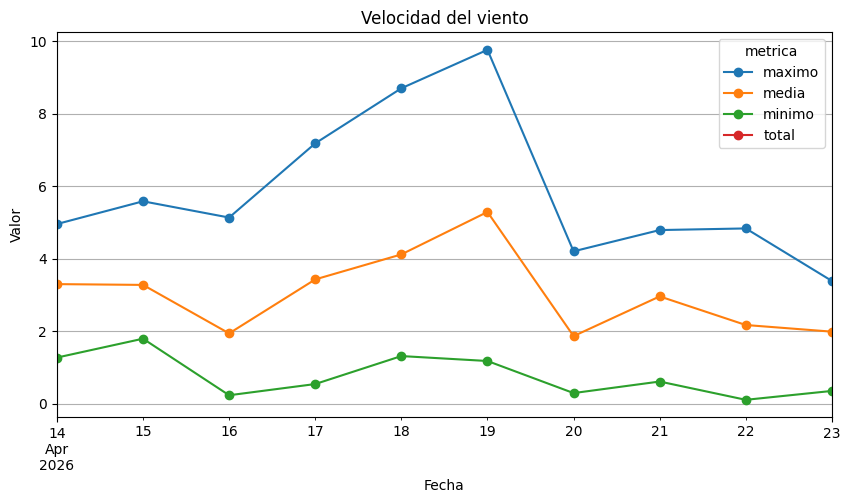

In [231]:
#Pivoteamos la tabla
df_wsp_plot = df_wsp.pivot(
    index='fecha_observacion',
    columns='metrica',
    values='valor'
)

#Graficamos
ax = df_wsp_plot.plot(figsize=(10,5), marker='o')
ax.set_ylabel("Valor")
ax.set_xlabel("Fecha")
plt.title("Velocidad del viento")
plt.grid(True)
plt.show()